<a href="https://colab.research.google.com/github/haydenhollar/study-hub/blob/master/ai102_final_project_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pinnacle Home Group New-Agent Onboarding Chatbot
A Retrieval-Based Chatbot Using TF-IDF and Cosine Similarity
Author: Hayden Hollar
Course: AI 102: Natural Language Processing with Python

Project Description
This notebook builds a retrieval-based chatbot that answers new-agent onboarding questions for a fictional real estate team, Pinnacle Home Group at Keller Williams. The chatbot does not generate answers with a language model. It matches each question against a fixed set of internal team documents (commission structure, team roster, policy manual, transaction checklists, and others) and returns the most relevant passage as the answer. The retrieval method is term frequency-inverse document frequency (TF-IDF) with cosine similarity, a standard NLP technique for finding the passage whose wording is closest to the question.

The key design choice is the refusal threshold. If the best match still scores below the threshold, the chatbot answers "I don't have that information" instead of guessing. This is the anti-hallucination mechanism the whole project is built around. A retrieval system can only repeat what is written in its source documents, so it cannot invent facts the way a generative model can.

Confidentiality Statement
Synthetic documents are used in place of proprietary brokerage materials. All team names, agent names, phone numbers, commission figures, and policies in this notebook are fictional and were created for this assignment. Nothing in this notebook reflects real Keller Williams materials, policies, or personnel.

There are a few installs needed for this ChatBot.

Regular Expressions (re) is used to find markedown headers when chunking.

Numpy is used for the similarity score bar chart below.

matplotlib.pyplot for plotting the similarity score chart in Cell 11.


NLP toolkit for tokenizing, stopwords and lemmatizing.

nltk.corps stopwords removes common words like "the", "is" which carry little meaning for matching.

WordnetLemmatizer reduces words to their dictionary root form. Ex. "closings" reduced to "closing".

The downloads form NLTK do not come with importing NLTK alone.

The additional packages provide sentence tokenizer models, list common English stopwords and a dictionary used by the lemmatizer.

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Setup complete: libraries imported and NLTK data downloaded.")


Setup complete: libraries imported and NLTK data downloaded.


The ChatBots Knowledge Base

This chatbot is a retrieval based bot using TF-IDF and cosine similarity so the documents it will find the answers from must be added. I used Claude to create 8 synthetic real estate documents to be used.

In [2]:
KNOWLEDGE_BASE = {
    'commission-fee-structure.md': "# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Commission & Fee Structure\n### Knox County, Tennessee\n\n**Document Type:** Internal Financial Reference\n**Last Updated:** August 2026\n**Maintained By:** Director of Operations — Claire Sutton\n**Confidential — Internal Use Only**\n\n---\n\n## How Does the KW Market Center Commission Structure Work?\n\n### What Is the Base Commission Split Before an Agent Caps?\n\n| Agent Level | Agent Receives | KW Market Center Receives |\n|---|---|---|\n| All agents pre-cap | 70% | 30% |\n\n### What Is the Annual Commission Cap at the KW Market Center?\n\n| Cap Type | Amount |\n|---|---|\n| Individual Agent Annual Cap | $18,000 |\n| Cap Period | January 1 – December 31 |\n\n> Once an agent pays $18,000 in commissions to the KW Market Center (the brokerage) in a calendar year, the agent moves to **Post-Cap status** for the remainder of that year.\n\n### What Commission Split Applies After an Agent Reaches Post-Cap Status?\n\n| Status | Agent Receives | KW Market Center Receives |\n|---|---|---|\n| Post-Cap | 100% | $0 (capped out) |\n\n> **Note:** The KW Royalty (see below) continues even post-cap.\n\n### What Is the KW International Royalty Rate and Cap?\n\n| Royalty | Rate | Cap |\n|---|---|---|\n| KW International Royalty | 6% of agent's gross commission | $3,000 per year maximum |\n\n> Royalty is paid to KWRI on every transaction until the $3,000 annual royalty cap is reached.\n\n---\n\n## How Does the Pinnacle Home Group Team Commission Structure Work?\n\n### What Is the Team Split Between the Agent and Pinnacle Home Group?\n\nAll agents on the Pinnacle Home Group team operate under the following team split structure **before** the KW Market Center split is applied:\n\n| Agent Status | Agent Receives (of GCI) | Team Receives (of GCI) |\n|---|---|---|\n| Year 1 (0–12 months on team) | 50% | 50% |\n| Year 2 (13–24 months) | 60% | 40% |\n| Year 3+ (25+ months) | 70% | 30% |\n| Senior Specialist (designated) | 75% | 25% |\n\n> **IMPORTANT:** The team split is applied FIRST. The remaining agent portion then flows through the KW Market Center split structure.\n\n### How Does an Agent's Team Cap Contribution Work?\n\n- Agents on the team contribute to the **team's** KW cap, not their own individual cap\n- Team cap: **$72,000** per calendar year\n- Once team cap is reached, all agent commissions go 100% to team (minus royalty) until year end\n- Individual agents do NOT maintain a separate personal cap while on the team\n\n---\n\n## What Transaction Fees Does Pinnacle Home Group Charge?\n\nThe following fees apply to every closed transaction:\n\n| Fee | Amount | Paid To | Notes |\n|---|---|---|---|\n| Transaction Fee | $395 | Pinnacle Home Group | Per closed side |\n| E&O Insurance Fee | $150 | KW Market Center | Per closed transaction |\n| MLS Fee Assessment | $25 | KAARMLS | Per transaction |\n| Compliance Review Fee | $75 | KW Market Center | Per transaction |\n\n> All fees are deducted from agent commissions at closing before disbursement.\n\n---\n\n## What Are Pinnacle Home Group's Referral Fee Policies?\n\n### What Referral Fee Is Paid When a Referral Is Sent to the Team?\n\n| Referral Type | Fee Paid to Referring Party |\n|---|---|\n| Standard inbound referral | 25% of team's gross commission on that side |\n| KW Referrals (internal KW network) | As negotiated, minimum 25% |\n| Luxury referral (over $1M) | 30–35% as negotiated |\n\n### What Referral Fee Does the Team Receive When It Sends a Lead to Another Agent?\n\n| Referral Type | Fee Received by Team |\n|---|---|\n| Standard outbound referral | 25% of receiving agent's gross commission |\n| KW Referrals (via Command Referrals) | As negotiated |\n\n> All referral agreements must be documented on a signed referral agreement before the referral is made. Contact Claire Sutton to initiate referral paperwork.\n\n### What Happens When an Agent Personally Refers a Client to Another Agent?\n\nIf a team agent personally refers a client to another agent outside the team:\n- Referral must be approved by Team Leader\n- Referral fee flows to the team first, then agent receives 50% of the referral income\n- All referral agreements must be executed through the team\n\n---\n\n## What Do Sample Commission Calculations Look Like?\n\n### What Does a Sample Commission Calculation Look Like for a Pre-Cap, Year 1 Agent?\n\n**Scenario:** $400,000 sale price, 3% buyer agent commission\n\n| Step | Calculation | Amount |\n|---|---|---|\n| Gross Commission | $400,000 × 3% | $12,000 |\n| Less: Team Split (Year 1, 50/50) | $12,000 × 50% to agent | $6,000 agent share |\n| Less: KW Market Center (30%) | $6,000 × 30% | ($1,800) |\n| Less: KW Royalty (6%, not yet capped) | $6,000 × 6% | ($360) |\n| Less: Transaction Fee | Flat | ($395) |\n| Less: E&O Fee | Flat | ($150) |\n| Less: MLS Assessment | Flat | ($25) |\n| Less: Compliance Fee | Flat | ($75) |\n| **Agent Net Commission** | | **$3,195** |\n\n---\n\n### What Does a Sample Commission Calculation Look Like for a Post-Cap, Year 3+ Agent?\n\n**Scenario:** $550,000 sale price, 3% listing commission\n\n| Step | Calculation | Amount |\n|---|---|---|\n| Gross Commission | $550,000 × 3% | $16,500 |\n| Less: Team Split (Year 3+, 70/30) | $16,500 × 70% to agent | $11,550 agent share |\n| Less: KW Market Center (post-cap) | $0 | $0 |\n| Less: KW Royalty (capped out) | $0 | $0 |\n| Less: Transaction Fee | Flat | ($395) |\n| Less: E&O Fee | Flat | ($150) |\n| Less: MLS Assessment | Flat | ($25) |\n| Less: Compliance Fee | Flat | ($75) |\n| **Agent Net Commission** | | **$10,905** |\n\n---\n\n### What Does a Sample Commission Calculation Look Like for a Year 2 Agent With a Referral Fee?\n\n**Scenario:** $350,000 sale, 3% buyer agent commission, 25% inbound referral fee\n\n| Step | Calculation | Amount |\n|---|---|---|\n| Gross Commission | $350,000 × 3% | $10,500 |\n| Less: Referral Fee (25%) | $10,500 × 25% | ($2,625) |\n| Net After Referral | | $7,875 |\n| Less: Team Split (Year 2, 60/40) | $7,875 × 60% to agent | $4,725 agent share |\n| Less: KW Market Center (30%) | $4,725 × 30% | ($1,417.50) |\n| Less: KW Royalty (6%) | $4,725 × 6% | ($283.50) |\n| Less: Transaction Fee | Flat | ($395) |\n| Less: E&O Fee | Flat | ($150) |\n| Less: MLS Assessment | Flat | ($25) |\n| Less: Compliance Fee | Flat | ($75) |\n| **Agent Net Commission** | | **$2,379** |\n\n---\n\n## How and When Is a Commission Disbursed After Closing?\n\n### How Is a Commission Check Paid Out?\n\n1. Title company issues commission check or wire at closing\n2. Checks are made payable to **Keller Williams Realty Knoxville**\n3. MCA processes the disbursement within 1–3 business days of closing\n4. Agent receives direct deposit (the commission check/paycheck) to bank account on file with KW\n5. Transaction fees are deducted before disbursement\n\n### How Does an Agent Set Up Direct Deposit for Commission?\n\n- Complete the ACH Direct Deposit Authorization form with the MCA\n- Contact Sandra Pierce: (865) 694-5904 ext. 102\n- Allow 1–2 pay cycles for new account to activate\n\n### How Are Commission Disputes Handled?\n\n- All commission disputes must be submitted in writing to Claire Sutton\n- Claire will escalate to Team Leader and MCA as needed\n- Commission disbursement authorization (CDA) must be signed before closing\n\n---\n\n## What Desk Fees and Additional Fees Does an Agent Pay?\n\n| Fee | Amount | Frequency | Notes |\n|---|---|---|---|\n| Monthly Team Desk Fee | $200 | Monthly | Covers office space, supplies, tech |\n| KW Technology Fee | $85 | Monthly | Command, KW app, platform access |\n| KAARMLS Dues | $540 | Annual | Knoxville Area Association of REALTORS® |\n| NAR Dues | $196 | Annual | National Association of REALTORS® |\n| TAR Dues | $165 | Annual | Tennessee Association of REALTORS® |\n| TN License Renewal | $75 | Every 2 years | Plus CE requirement |\n| KW Associate Fee | $25 | Monthly | KW International membership |\n\n---\n\n## What Are the Minimum Production Requirements to Stay on the Team?\n\n### What Are the Minimum Closed-Transaction and GCI Requirements?\n\nAgents on the Pinnacle Home Group team are expected to meet the following minimum production requirements to remain on the team:\n\n| Period | Minimum Closed Transactions | Minimum GCI |\n|---|---|---|\n| First 6 months | 3 closed sides | $15,000 GCI |\n| First 12 months | 8 closed sides | $40,000 GCI |\n| Ongoing (annual) | 12 closed sides | $60,000 GCI |\n\n> Agents not meeting minimum production standards will be placed on a 60-day performance improvement plan. Failure to meet performance plan requirements may result in separation from the team.\n\n---\n\n*End of Commission & Fee Structure — Pinnacle Home Group*\n*Questions: Contact Claire Sutton at claire@pinnacleknox.com or (865) 500-1100*\n*Last Updated: August 2026 — Confidential Internal Document*\n",
    'team-roster.md': '# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Team Roster & Organizational Chart\n### Knox County, Tennessee\n\n**Document Type:** Internal Operations Reference\n**Last Updated:** August 2026\n**Maintained By:** Team Operations\n**Confidential — Internal Use Only**\n\n---\n\n## How Is Pinnacle Home Group Organized?\n\nPinnacle Home Group at Keller Williams is organized as follows:\n\n- **Team Leader / Operating Principal:** Hayden Hollar\n- **Operations**\n  - Director of Operations: Claire Sutton\n  - Transaction Coordinator (TC): Megan Forsythe\n  - Administrative Assistant: Brittany Ogle\n- **Sales — Buyer Specialists**\n  - Senior Buyer Specialist: Jake Whitmore\n  - Buyer Specialist: Tara London\n  - Buyer Specialist: Devon Marsh\n  - Buyer Specialist / New Agent: Callie Nguyen\n- **Sales — Listing Specialists**\n  - Lead Listing Specialist: Ryan Blackwell\n  - Listing Specialist: Susan Pratt\n  - Listing Specialist: Marcus Webb\n- **Showing Assistants**\n  - Parker Hines\n  - Alicia Tran\n- **Marketing**\n  - Marketing Coordinator: Jordan Ellis\n\n---\n\n## Who Is on the Pinnacle Home Group Team, and How Do I Contact Them?\n\n---\n\n### Who Is on the Pinnacle Home Group Leadership Team?\n\n---\n\n**Hayden Hollar**\nTitle: Team Leader / Operating Principal\nPhone: (865) 500-1000\nEmail: hayden@pinnacleknox.com\nOffice: 9041 Executive Park Drive, Suite 200, Knoxville, TN 37923\nLicense: TN Real Estate License #00341892\nSpecialties: Team strategy, luxury listings, complex negotiations, investor clients\nAvailability: M–F 8am–7pm, Sat 9am–5pm\nNotes: Final decision-making authority on all team matters. Contact Hayden Hollar, the team leader (also referred to as the boss), for escalated client issues, contract disputes, and agent policy questions.\n\n---\n\n**Claire Sutton**\nTitle: Director of Operations\nPhone: (865) 500-1100\nEmail: claire@pinnacleknox.com\nLicense: TN Real Estate License #00412204\nSpecialties: Transaction management, compliance, vendor coordination, agent support\nAvailability: M–F 8am–5pm\nNotes: First point of contact for all operational questions. Manages Transaction Coordinator (TC) workflow, compliance submissions, and vendor relationships. All new transactions should be opened with Claire.\n\n---\n\n### Who Is the Pinnacle Home Group Transaction Coordinator?\n\n---\n\n**Megan Forsythe**\nTitle: Transaction Coordinator (TC)\nPhone: (865) 500-1120\nEmail: megan@pinnacleknox.com\nSpecialties: Contract to close management, compliance document submission, deadline tracking, commission disbursement\nAvailability: M–F 8:30am–5pm\nNotes: Megan Forsythe is the assigned Transaction Coordinator (TC) for all team transactions. Agents must submit fully executed contract to Megan within 24 hours of acceptance. She manages all deadlines from contract through closing.\n\n---\n\n### Who Are the Pinnacle Home Group Listing Specialists?\n\n---\n\n**Ryan Blackwell**\nTitle: Lead Listing Specialist\nPhone: (865) 500-1200\nEmail: ryan@pinnacleknox.com\nLicense: TN Real Estate License #00388841\nSpecialties: Listing appointments, pricing strategy, seller negotiations, expired listings, FSBO conversion\nAvailability: M–Sa 8am–7pm\nCoverage Areas: West Knoxville, Farragut, Hardin Valley\nNotes: Lead listing agent. Handles all luxury listings above $750K. Also leads weekly sales huddle on Tuesdays at 9am.\n\n---\n\n### Who Are the Pinnacle Home Group Buyer Specialists?\n\n---\n\n**Jake Whitmore**\nTitle: Senior Buyer Specialist\nPhone: (865) 500-1300\nEmail: jake@pinnacleknox.com\nLicense: TN Real Estate License #00355991\nSpecialties: Move-up buyers, relocation buyers, new construction, negotiation\nAvailability: M–Su 8am–8pm\nCoverage Areas: All Knox County, Blount County, Loudon County\nNotes: Highest volume buyer agent on the team. Expert in multiple offer situations and escalation clauses.\n\n---\n\n### Who Handles Marketing for Pinnacle Home Group?\n\n---\n\n**Jordan Ellis**\nTitle: Marketing Coordinator\nPhone: (865) 500-1500\nEmail: jordan@pinnacleknox.com\nSpecialties: Listing marketing, social media content, email campaigns, graphic design, photography coordination, print marketing\nAvailability: M–F 9am–5pm\nNotes: Submit all marketing requests to Jordan with minimum 48-hour notice. Listing marketing requests must include MLS number, photos, and key features. Manages team Instagram, Facebook, and Google Business Profile.\n\n---\n\n## Who Are the Key Contacts at the KW Market Center?\n\n---\n\n**Keller Williams Realty — Knoxville**\nAddress: 9041 Executive Park Drive, Suite 200, Knoxville, TN 37923\nMain Office: (865) 694-5904\nFax: (865) 694-5910\nMarket Center Website: www.kwknoxville.com\n\n**Market Center Principal Broker**\nName: Thomas B. Gilliam\nPhone: (865) 694-5904 ext. 101\nEmail: thomas.gilliam@kw.com\nLicense: TN Broker License #00218844\n\n**Market Center Administrator (MCA)**\nName: Sandra Pierce\nPhone: (865) 694-5904 ext. 102\nEmail: sandra.pierce@kw.com\nNotes: Contact Sandra for compliance questions, commission disbursement issues, and MCA approvals.\n\n**Compliance Coordinator**\nName: Rebecca Holt\nPhone: (865) 694-5904 ext. 103\nEmail: rebecca.holt@kw.com\nNotes: Primary contact for document compliance submissions. Rebecca reviews all compliance packages.\n\n**Tech/Command Support**\nName: Liam Carter\nPhone: (865) 694-5904 ext. 110\nEmail: liam.carter@kw.com\nNotes: Command questions, login issues, MLS sync problems.\n\n---\n\n*End of Team Roster — Pinnacle Home Group at Keller Williams*\n*For updates contact Claire Sutton at claire@pinnacleknox.com*\n*Last Updated: August 2026 — Confidential Internal Document*\n',
    'team-policy-manual.md': '# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Team Policy & Procedures Manual\n### Knox County, Tennessee\n\n**Document Type:** Internal Policy Manual\n**Version:** 4.0\n**Last Updated:** August 2026\n**Effective Date:** January 1, 2026\n**Maintained By:** Director of Operations — Claire Sutton\n**Approved By:** Hayden Hollar — Team Leader\n**Confidential — Internal Use Only**\n\n---\n\n## What Are Pinnacle Home Group\'s Communication Standards?\n\n### What Are the Required Client Response Times?\n\n| Communication Type | Required Response Time |\n|---|---|\n| Client phone calls | Within 2 hours during business hours |\n| Client text messages | Within 1 hour during business hours |\n| Client emails | Within 3 hours during business hours |\n| Team member communications | Within 1 hour during business hours |\n| Cooperating agent communications | Within 2 hours during business hours |\n| After hours client emergency | Within 30 minutes |\n\n> **Business hours** are defined as 8:00 AM – 7:00 PM Monday through Saturday and 10:00 AM – 5:00 PM Sunday.\n\n> Agents are expected to set up voicemail and auto-reply indicating response times and after-hours emergency contact.\n\n### What Communication Channels Does the Team Use?\n\n- **Phone/Text:** Primary method for client communication\n- **Email:** Used for formal correspondence, document transmission, and written confirmation of verbal agreements\n- **Command:** All contact notes, activity logs, and task management must be maintained in KW Command\n- **Team GroupMe:** Team-wide announcements and quick coordination\n- **Slack:** Operations channel for Transaction Coordinator (TC), admin, and agent workflow communication\n\n### How Must Client Interactions Be Logged?\n\nEvery client interaction must be logged in Command within 24 hours:\n- Phone calls — log duration, summary, and next action\n- Showings — log property, buyer reaction, and follow-up plan\n- Offers — log submission time, terms, and response\n- Negotiations — log all counter offers and conversations\n\nFailure to maintain Command log entries will be reviewed in weekly accountability check-ins.\n\n---\n\n## What Is the Team\'s Lead Management Policy?\n\n### Who Owns a Lead Based on Its Source?\n\n| Lead Source | Assigned To | Notes |\n|---|---|---|\n| Team-generated online leads | Assigned by Director of Operations | Round-robin with performance weighting |\n| Agent self-generated leads | Assigned agent | Agent owns this relationship |\n| Referral leads | Agent who received referral | Must document in Command |\n| Open house leads | Agent hosting open house | Captured same day in Command |\n| Database/sphere leads | Original agent of record | |\n| Unassigned expired leads (90+ days) | Available to any agent | With Director of Operations approval |\n\n### How Quickly Must a Team-Assigned Lead Be Contacted?\n\nAll team-assigned leads must be:\n- Called within **5 minutes** of notification during business hours\n- Followed up with text if no answer within **15 minutes**\n- Logged in Command within **1 hour** of first contact attempt\n- Placed on appropriate SmartPlan within **24 hours**\n\n> Leads not contacted within 5 minutes during business hours may be reassigned at the Director of Operations\' discretion.\n\n### When Can a Lead Be Reassigned?\n\nLeads may be reassigned if:\n- Agent fails to make contact attempt within required timeframe\n- Agent is unavailable for more than 48 hours without prior notice\n- Client requests a different agent\n- Agent leaves the team\n\n---\n\n## What Is the Team\'s Transaction Management Policy?\n\n### What Must an Agent Do When a Contract Is Executed?\n\nWhen a contract is executed (signed by all parties), the agent must:\n1. Submit fully executed contract to Megan Forsythe, the team\'s Transaction Coordinator (TC), within **24 hours**\n2. Email cooperating agent and lender the contract with all addenda\n3. Open the Opportunity in Command and update to correct pipeline stage\n4. Confirm earnest money instructions with title company\n5. Log all key dates in Command Opportunity detail screen\n\n### When Must Earnest Money Be Delivered to the Escrow Holder?\n\nEarnest money (the buyer\'s good-faith deposit) must be delivered to\nthe designated escrow holder within the timeframe stated in the\ncontract, typically within 2 business days of the effective date.\nThe agent must confirm receipt of earnest money with the escrow\nholder and document it in Command. If earnest money is not received\non time, the agent must notify the Team Leader immediately.\n\n### Who Tracks Contract Deadlines?\n\nMegan Forsythe, the Transaction Coordinator (TC), tracks all contract\ndeadlines. However, agents are responsible for knowing and\ncommunicating their own deadlines. Ignorance of a deadline is not an\nacceptable excuse for a missed contingency.\n\nCritical deadlines agents must personally monitor:\n- Earnest money delivery\n- Inspection period expiration\n- Financing commitment deadline\n- Appraisal deadline\n- Closing date\n\n### How Are Compliance Documents Submitted?\n\n- All compliance documents must be submitted through Command → Opportunities → Compliance\n- Submissions must be made no later than 48 hours before the closing date\n- The MCA/Compliance Coordinator must approve documents before funds are released\n\n### What Are the Agent\'s Responsibilities at Closing?\n\n- Agent must attend all closings unless prior approval granted by Team Leader\n- Agent must confirm closing time with title company 48 hours in advance\n- Drive-by or remote closes require Team Leader approval\n- Closing gift must be arranged at least 5 business days before closing date\n\n---\n\n## What Is Pinnacle Home Group\'s Marketing and Social Media Policy?\n\n### What Rules Apply to an Agent\'s Personal Social Media?\n\nAgents may maintain personal real estate social media accounts subject to the following:\n- All posts must comply with Fair Housing Act — no steering language\n- All posts must include TN license number and "Pinnacle Home Group at KW" affiliation\n- No listing content may be posted before MLS activation\n- No client information may be shared without written client consent\n- No testimonial may be fabricated or incentivized\n- All advertising must comply with KAARMLS, TAR, and NAR advertising guidelines\n\n### How Must the Team Brand Be Used?\n\n- Pinnacle Home Group logo must be used on all co-branded materials\n- KW logo and branding must comply with KW brand standards\n- Contact Jordan Ellis for approved logo files and brand assets\n- Do not create team-branded materials without Jordan Ellis approval\n\n### What Rules Apply to Off-Market and Pocket Listings?\n\nAny off-market listing promotion must comply with KAARMLS Clear Cooperation Policy:\n- Properties must be submitted to MLS within 1 business day of marketing to the public\n- Private exclusive listings permitted only with written seller exemption on file\n\n---\n\n## What Are the Team\'s Scheduling and Availability Requirements?\n\n### What Minimum Availability Must an Agent Maintain?\n\nAll agents must maintain the following minimum availability:\n- Minimum 5 days per week available for client appointments\n- Must be reachable by phone during business hours defined in Section 2\n- Extended absence (3+ business days) requires advance notice to Director of Operations\n- Coverage agent must be arranged for any absence exceeding 2 business days\n\n### How Does an Agent Request Time Off?\n\n- Notify Claire Sutton minimum 5 business days in advance for planned PTO\n- All active clients must be covered by a designated team agent during absence\n- Coverage arrangements must be documented and client notified of coverage agent\n\n### What Are the Team Meeting Attendance Requirements?\n\nSee Section 13 for meeting requirements.\n\n---\n\n## How Are Conflicts Resolved on the Team?\n\n### How Are Agent-to-Agent Disputes Resolved?\n\n1. Agents attempt to resolve directly\n2. If unresolved, escalate to Director of Operations within 48 hours\n3. If unresolved at that level, Team Leader makes final determination\n\n### How Are Agent-Client Disputes Resolved?\n\n1. Agent notifies Director of Operations immediately\n2. Team Leader notified within 24 hours\n3. Team Leader may assume management of client relationship if needed\n4. Legal counsel (Harrington & Moore Law Group) consulted if risk of complaint or litigation\n\n### How Are Commission Disputes With Co-op Agents Resolved?\n\n1. Document all facts in writing\n2. Escalate to Team Leader immediately\n3. If required, escalate to KAARMLS Ethics or Arbitration\n\n---\n\n*End of Team Policy & Procedures Manual — Pinnacle Home Group*\n*Approved by: Hayden Hollar, Team Leader — August 2026*\n*Next Review Date: January 1, 2027*\n*Questions: Claire Sutton — claire@pinnacleknox.com — (865) 500-1100*\n',
    'buyer-process-checklist.md': "# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Buyer Process Checklist\n### From Initial Contact to Closing\n\n**Team:** Pinnacle Home Group | Knox County, TN\n**Version:** 2.0 | August 2026\n\n---\n\n## How Should an Agent Respond to a New Buyer Lead?\n\n- [ ] Respond to inquiry within 5 minutes during business hours\n- [ ] Qualify lead — determine:\n  - [ ] Are they pre-approved? If not, refer to preferred lender immediately\n  - [ ] What is their timeline? (Now, 3 months, 6+ months)\n  - [ ] Renting or owning currently?\n  - [ ] Price range / budget\n  - [ ] Geographic preference (area of Knox County)\n  - [ ] Type of home (single family, condo, new construction)\n  - [ ] Key must-haves\n  - [ ] Motivation for buying\n- [ ] Add to Command contact database immediately\n- [ ] Tag appropriately (Buyer Lead, Hot/Warm/Cold, Timeline)\n- [ ] Assign to SmartPlan based on timeline\n- [ ] Schedule buyer consultation\n\n---\n\n## What Happens During the Buyer Consultation?\n\n- [ ] Complete buyer needs assessment (see Buyer Needs Assessment form in KC)\n- [ ] Explain current market conditions\n- [ ] Explain PHG buyer process and team structure\n- [ ] Review buyer agent representation — explain Buyer Representation Agreement\n- [ ] Execute Buyer Representation Agreement before first showing\n- [ ] Confirm and review buyer agent compensation with buyer\n- [ ] Confirm lender referral or confirm they have pre-approval\n- [ ] Review pre-approval letter — confirm:\n  - [ ] Loan amount sufficient for target price range\n  - [ ] Pre-approval not expired\n  - [ ] Lender is reputable (verify if unfamiliar lender)\n- [ ] Set up MLS auto-search to buyer's criteria\n- [ ] Confirm communication preferences (text, email, call)\n\n---\n\n## How Does the Home Search Process Work for a Buyer?\n\n- [ ] Active MLS auto-search running and sending listings to buyer\n- [ ] Review listings with buyer regularly\n- [ ] Schedule showings promptly — within 24 hours of buyer interest\n- [ ] Prepare for each showing:\n  - [ ] Review MLS listing thoroughly\n  - [ ] Check days on market and price history\n  - [ ] Pull comparable sales if property looks like a strong candidate\n  - [ ] Know showing instructions — schedule via ShowingTime\n- [ ] Conduct showings professionally:\n  - [ ] Arrive 5 minutes before buyers\n  - [ ] Confirm lockbox accessible\n  - [ ] Walk through with buyers — highlight positives and flag concerns\n  - [ ] Point out items relevant to inspection (age of roof, HVAC, etc.)\n  - [ ] Discuss pricing relative to market after showing\n- [ ] Collect buyer feedback after every showing\n- [ ] Update buyer profile and search criteria based on feedback\n\n---\n\n## How Does an Agent Prepare a Buyer's Offer?\n\n- [ ] Pull recent comparable sales to support offer price\n- [ ] Review current competition — any other offers or showing activity?\n- [ ] Discuss offer strategy with buyer:\n  - [ ] Price\n  - [ ] Financing contingency terms\n  - [ ] Inclusions / exclusions\n  - [ ] Seller concessions if applicable\n- [ ] Complete Offer Writing Checklist (see separate checklist in KC)\n- [ ] Prepare Tennessee Purchase and Sale Agreement\n- [ ] Prepare Pre-Approval Letter to accompany offer\n- [ ] Prepare Proof of Funds if cash offer or large down payment\n- [ ] Draft cover letter (optional — humanizes buyer)\n- [ ] Submit offer to listing agent per their instructions\n- [ ] Confirm offer received by listing agent\n- [ ] Monitor response — seller has set timeframe to respond\n\n### What Earnest Money Deposit Should a Pinnacle Home Group Buyer Offer?\nFor a Pinnacle Home Group buyer offer, the earnest money deposit\n(also called earnest money, or EM) is a minimum of $1,000, and is\ntypically 1–2% of the purchase price. The buyer's agent should\ndiscuss the exact earnest money amount with the buyer while\npreparing the offer.\n\n### How Long Is the Inspection Period for a Pinnacle Home Group Buyer Offer?\nThe standard inspection period length for a Pinnacle Home Group\nbuyer offer is 10 days from acceptance, per typical Knox County\npractice. This is the window during which the buyer must complete\ninspections and negotiate any repair requests before the inspection\ncontingency is removed.\n\n### When Is the Closing Date for a Pinnacle Home Group Buyer Offer?\nThe closing date for a Pinnacle Home Group buyer offer is typically\n30–45 days from acceptance of the offer, though the exact date is\nnegotiated and stated in the purchase agreement.\n\n### Does Pinnacle Home Group Allow Escalation Clauses in Buyer Offers?\nYes. Pinnacle Home Group allows an escalation clause on a buyer offer\nwhen the property is in a multiple-offer environment. The buyer's\nagent should discuss whether an escalation clause is appropriate for\nthe specific offer while preparing the offer strategy with the buyer.\n\n---\n\n## What Happens Once a Buyer Is Under Contract?\n\n- [ ] Follow Buyer Side Transaction Checklist immediately upon acceptance\n- [ ] All deadlines tracked by the Transaction Coordinator (TC) and agent\n\n---\n\n*Document: PHG Buyer Process Checklist | Version 2.0 | August 2026*\n",
    'listing-process-checklist.md': "# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Listing Process Checklist\n### From Signed Listing Agreement to Active in MLS\n\n**Team:** Pinnacle Home Group | Knox County, TN\n**Version:** 2.0 | August 2026\n\n---\n\n## What Happens Once the Listing Agreement Is Signed?\n\n- [ ] Confirm all signatures on listing agreement — all sellers on title\n- [ ] Confirm all terms: list price, commission, listing period, inclusions/exclusions\n- [ ] Enter listing into Command Opportunities\n- [ ] Add sellers to Command contact database\n- [ ] Send listing agreement to Transaction Coordinator (TC) for compliance file\n- [ ] Request all seller disclosure forms be completed within 3 business days\n\n---\n\n## What Pre-Listing Preparation Happens in the First Week?\n\n### How Many Hours Before the List Date Should the Photographer Be Scheduled?\n- [ ] Schedule professional photographer (minimum 48 hours before desired list date)\n- [ ] Schedule staging consultation if needed\n- [ ] Order lockbox — install at property and document code\n- [ ] Order yard sign — confirm sign placement with seller\n\n### What Are the Showing Access, Notice, and Preparation Instructions?\n- [ ] Confirm showing instructions with seller:\n  - [ ] Appointment only or go and show?\n  - [ ] Notice required (1 hour, 24 hours)?\n  - [ ] Showing times permitted\n  - [ ] Pets to be removed?\n  - [ ] Seller present or vacant?\n  - [ ] Security cameras — disclose in MLS if applicable\n- [ ] Advise seller on showing prep (refer to Photo Prep & Showing Prep checklist)\n\n### Which Disclosure Documents Are Required Before Listing?\n- [ ] Complete Tennessee Residential Property Condition Disclosure with seller\n- [ ] Complete Lead-Based Paint Disclosure (homes built before 1978)\n- [ ] Complete all other applicable disclosures (mold, radon, HOA, flood)\n- [ ] Upload all signed disclosures to compliance folder\n\n### How Should the Agent Prepare for the Listing Photography Appointment?\n- [ ] Confirm photo appointment with seller\n- [ ] Send seller the Photo Prep Checklist\n- [ ] Confirm photographer will also capture drone, twilight, or video if ordered\n- [ ] Confirm Matterport / 3D tour if included in listing package\n\n---\n\n## What Happens During MLS Input Before the Listing Goes Live?\n\n### What Property Details Are Gathered Before Inputting a Listing Into MLS?\n- [ ] Gather all property details for MLS input:\n  - [ ] Address and legal description\n  - [ ] Square footage (use assessor data — note source)\n  - [ ] Bedroom and bathroom count\n  - [ ] Year built\n  - [ ] Garage type and spaces\n  - [ ] Lot size in acres and sq ft\n  - [ ] School district (Knox County Schools — confirm zone)\n  - [ ] HOA status, dues, and contact\n  - [ ] Property taxes (most recent annual amount)\n  - [ ] Utilities: gas, electric, water, sewer or septic\n  - [ ] HVAC type, age, number of units\n  - [ ] Roof age (approximate)\n  - [ ] Water heater type and age\n  - [ ] All inclusions and exclusions\n  - [ ] Showing instructions and access information\n  - [ ] Lockbox location\n- [ ] Write listing description (use AI assist or approved template)\n- [ ] Input all data into MLS system — double check all fields\n- [ ] Upload all photos in correct order — primary photo most compelling exterior shot\n- [ ] Upload floor plan if available\n- [ ] Add virtual tour link if applicable\n- [ ] Set list price per approved listing agreement\n- [ ] Confirm buyer agent compensation in MLS (per updated NAR settlement requirements)\n- [ ] Set availability date — do not go active before confirmed with seller\n- [ ] Review entire MLS listing for accuracy before activating\n\n---\n\n## What Happens on Marketing Launch Day?\n\n### What Digital Marketing Steps Happen on Launch Day?\n- [ ] Confirm MLS listing is active — verify data accuracy live\n- [ ] Confirm listing is syndicating to Zillow, Realtor.com, Redfin, and KW.com\n- [ ] Create Just Listed social media posts:\n  - [ ] Facebook\n  - [ ] Instagram\n  - [ ] LinkedIn (optional)\n- [ ] Send Just Listed email to sphere and database (see email template in KC)\n- [ ] Post listing to neighborhood Facebook groups (where permitted)\n- [ ] Set up Facebook / Instagram paid ad if approved for listing (see marketing budget policy)\n- [ ] Share listing in KW agent network for co-op exposure\n\n### What Physical Marketing Steps Happen on Launch Day?\n- [ ] Confirm yard sign is installed\n- [ ] Confirm lockbox is installed and code works\n- [ ] Print property flyer / feature sheet if needed for showing box or open house\n\n---\n\n## How Is an Active Listing Managed?\n\n- [ ] Monitor showing requests daily — confirm seller is being notified\n- [ ] Collect showing feedback within 24 hours of each showing\n- [ ] Share showing feedback with seller weekly or after each showing\n- [ ] Review activity with seller weekly — showings, online views, inquiries\n- [ ] Monitor competing listings — adjust strategy if new competition enters market\n- [ ] Evaluate price reduction after 2 weeks with no offers if priced above market\n- [ ] Update MLS listing if any changes in status, terms, or property condition\n- [ ] Maintain lockbox batteries and sign condition throughout listing period\n\n---\n\n## What Happens When an Offer Is Received on a Listing?\n\n- [ ] Present all offers to seller promptly — do not delay\n- [ ] Prepare offer comparison sheet if multiple offers\n- [ ] Review all terms with seller:\n  - [ ] Purchase price\n  - [ ] Earnest money amount\n  - [ ] Financing contingency terms\n  - [ ] Inspection period length\n  - [ ] Proposed closing date\n  - [ ] Inclusions / exclusions\n  - [ ] Repair or concession requests\n  - [ ] Buyer agent compensation if applicable\n- [ ] Advise on market conditions and how offer compares\n- [ ] Accept, counter, or reject — document seller's decision\n- [ ] Execute signed contract — follow Transaction Checklist Seller Side\n\n---\n\n## How Is an Un-Contracted Listing Maintained Over Time?\n\n### What Happens If There's No Offer After 21 Days?\n- [ ] Schedule price strategy review with seller\n- [ ] Prepare updated CMA with any new comparable sales\n- [ ] Discuss price reduction if appropriate\n- [ ] If price reduced — update MLS immediately and re-market as price improvement\n\n### What Happens as a Listing Approaches Expiration?\n- [ ] Contact seller 30 days before expiration\n- [ ] Discuss renewal if still wanting to sell\n- [ ] Prepare new listing agreement or extension addendum\n- [ ] Reassess pricing and marketing strategy\n\n---\n\n*Document: PHG Listing Process Checklist | Version 2.0 | August 2026*\n",
    'under-contract-timeline-and-deadline-tracker.md': '# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Under Contract Timeline & Deadline Tracker\n### Knox County, Tennessee\n\n**Version:** 2.0 | August 2026\n**Maintained By:** Megan Forsythe — Transaction Coordinator (TC)\n\n---\n\n## How Should This Tracker Be Used?\n\n- Complete immediately upon contract execution\n- Enter effective date and calculate all deadlines on Day 0\n- Share with buyer or seller client at the "Under Contract Next Steps"\n  call\n- Upload completed tracker to Command Opportunity\n- All deadlines are calculated from the Effective Date (the date the\n  last party signs the contract)\n\n---\n\n## What Transaction Information Should Be Filled In for This Deal?\n\nProperty Address: _________________________________________\nMLS Number: ______________________________________________\nEffective Date (Day 0): ____________________________________\nProjected Closing Date: ___________________________________\nContract Purchase Price: __________________________________\nEarnest Money Amount: _____________________________________\nLoan Type: _______________________________________________\n\n**Parties:**\nBuyer(s): ________________________________________________\nSeller(s): _______________________________________________\nBuyer Agent: _____________________________________________\nListing Agent: ___________________________________________\nLender / Loan Officer: ___________________________________\nLender Phone: ____________________________________________\nTitle Company: ___________________________________________\nTitle Officer: ___________________________________________\nTitle Phone: _____________________________________________\n\n---\n\n## What Are the Critical Deadlines for This Transaction?\n\n### When Is Earnest Money Due and Confirmed?\n| Item | Timeframe | Calculated Date | Completed |\n|---|---|---|---|\n| Earnest money delivered to title | Day 2 from effective date | _________ | [ ] |\n| EMD receipt obtained from title | Within 24 hrs of delivery | _________ | [ ] |\n\n### What Are the Loan and Financing Deadlines?\n| Item | Timeframe | Calculated Date | Completed |\n|---|---|---|---|\n| Buyer submits loan application | Day 3 from effective date | _________ | [ ] |\n| Loan Estimate delivered to buyer | Day 3 from application | _________ | [ ] |\n| Appraisal ordered by lender | Day 5 (estimated) | _________ | [ ] |\n| Financing commitment letter | Day 21 from effective date | _________ | [ ] |\n| Appraisal received (estimated) | Day 21–28 (varies) | _________ | [ ] |\n| Closing Disclosure to buyer | 3 business days before closing | _________ | [ ] |\n\n### What Are the Inspection-Related Deadlines?\n| Item | Timeframe | Calculated Date | Completed |\n|---|---|---|---|\n| Inspection period ends | Day 10 from effective date | _________ | [ ] |\n| All inspections completed | Before Day 10 | _________ | [ ] |\n| Repair request submitted to seller | Before Day 10 | _________ | [ ] |\n| Seller response to repair request | 5 business days after receipt | _________ | [ ] |\n| Buyer response to seller reply | 2 business days after seller | _________ | [ ] |\n| Inspection resolution executed | Before inspection period ends | _________ | [ ] |\n\n### What Are the Title and HOA Review Deadlines?\n| Item | Timeframe | Calculated Date | Completed |\n|---|---|---|---|\n| Title commitment issued | Day 10 from effective date | _________ | [ ] |\n| HOA docs delivered to buyer | Day 10 from effective date | _________ | [ ] |\n| HOA review period ends | Day 5 after receipt | _________ | [ ] |\n| Title exceptions cleared | Before closing | _________ | [ ] |\n\n### What Are the Seller Disclosure Deadlines?\n| Item | Timeframe | Calculated Date | Completed |\n|---|---|---|---|\n| Seller disclosures delivered | Day 5 from effective date | _________ | [ ] |\n| Buyer acknowledgment received | Within 3 days of delivery | _________ | [ ] |\n| Lead paint disclosure delivered | Day 5 (if pre-1978 home) | _________ | [ ] |\n\n### What Must Be Completed Before Closing?\n| Item | Timeframe | Calculated Date | Completed |\n|---|---|---|---|\n| All contingencies satisfied | 5 days before closing | _________ | [ ] |\n| All negotiated repairs completed | 3 days before closing | _________ | [ ] |\n| Repair receipts obtained | 3 days before closing | _________ | [ ] |\n| Insurance binder to lender | 5 days before closing | _________ | [ ] |\n| Final walk-through scheduled | 24–48 hrs before closing | _________ | [ ] |\n| Final walk-through completed | 24–48 hrs before closing | _________ | [ ] |\n| Wire Fraud Warning delivered | Day 1 from effective date | _________ | [ ] |\n| CDA submitted to MCA | 48 hrs before closing | _________ | [ ] |\n\n### What Is the Expected Closing Date, Time, and Location?\nFor a Pinnacle Home Group buyer, the closing date is typically 30–45\ndays from the effective date (the date the contract is fully signed)\n— confirm the exact date in the purchase agreement, since it is\nnegotiated per contract rather than fixed. Closing time and location\nare confirmed with the title company and all parties in the days\nbefore closing; the location is normally the title company\'s office\nunless every party agrees otherwise.\n\n| Item | Timeframe | Calculated Date (this deal) | Completed |\n|---|---|---|---|\n| Closing date | Typically 30–45 days from effective date (confirm in contract) | _________ | [ ] |\n| Closing time | Confirmed with title company before closing | _________ | [ ] |\n| Closing location | Title company\'s office, unless otherwise agreed | _________ | [ ] |\n\n---\n\n## What Does the Day-by-Day Transaction Timeline Look Like?\n\n**Day 0 — Effective Date**\n- Contract fully executed\n- Notify all parties\n- Open file in Command\n- Begin deadline calculations\n\n**Day 1–2**\n- Earnest money delivered\n- Wire fraud warning delivered to buyer\n- Contract sent to lender and title\n\n**Day 3**\n- Buyer submits loan application\n- Lender sends Loan Estimate to buyer\n\n**Day 5**\n- Seller disclosures delivered to buyer\n- Inspection scheduled (if not already done)\n\n**Day 7–10**\n- All inspections completed\n- Repair request submitted (if applicable)\n- HOA documents delivered\n- Title commitment issued\n\n**Day 10**\n- INSPECTION PERIOD EXPIRES\n- All inspection decisions must be made by end of Day 10\n\n**Day 11–15**\n- Seller responds to repair request\n- Buyer responds to seller\'s position\n- Inspection resolution executed\n\n**Day 21**\n- Financing commitment letter due\n- Appraisal typically completed around this time\n\n**Day 22–25**\n- Review appraisal results\n- Renegotiate if appraisal is below purchase price\n- If appraisal contingency — buyer has 3 days to act\n\n**5 Days Before Closing**\n- All contingencies must be satisfied\n- Insurance binder delivered to lender\n- All repairs completed and receipts obtained\n\n**3 Business Days Before Closing**\n- Closing Disclosure delivered to buyer (federal requirement)\n- Buyer reviews cash to close amount\n\n**24–48 Hours Before Closing**\n- Final walk-through completed\n- Any last-minute issues resolved\n\n**Closing Day**\n- Confirm time and location with all parties\n- Buyer brings ID and certified funds or confirms wire\n- Keys transfer at recording\n\n---\n\n## What Is the Status of Each Contingency?\n\n| Contingency | Deadline | Status | Notes |\n|---|---|---|---|\n| Inspection Contingency | Day 10 | Active / Removed / Waived | |\n| Financing Contingency | Day 21 | Active / Removed / Waived | |\n| Appraisal Contingency | Day 21–25 | Active / Removed / Waived | |\n| HOA Review | Day 10–15 | Active / Removed / Waived | |\n| Title Review | Day 10 | Active / Removed / Waived | |\n| Sale of Buyer\'s Home | ________ | Active / Removed / Waived | |\n\n---\n\n## What Should an Agent Do If a Deadline Is Missed?\n\nIf any deadline is missed or at risk:\n\n1. Notify agent immediately by text AND call\n2. Agent notifies opposing agent to discuss cure or extension\n3. Document all communications in Command notes\n4. Execute written extension addendum if needed\n5. Notify Megan Forsythe (Transaction Coordinator) and Claire Sutton of any deadline extension\n6. Update this tracker with revised dates\n\n**Never let a deadline pass silently. Always address in writing.**\n\n---\n\n## Are There Any Special Circumstances to Note for This Deal?\n\n________________________________________________________________\n________________________________________________________________\n________________________________________________________________\n________________________________________________________________\n\n---\n\n*Document: PHG Under Contract Timeline & Deadline Tracker | v2.0 | August 2026*\n*Pinnacle Home Group at Keller Williams — Knox County, TN*\n*TC contact: Megan Forsythe — megan@pinnacleknox.com — (865) 500-1120*\n',
    'closing-day-checklist.md': "# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Closing Day Checklist\n### Buyer Side & Seller Side\n\n**Version:** 2.0 | August 2026\n**Maintained By:** Megan Forsythe — Transaction Coordinator (TC)\n\n---\n\n# PART 1 — CLOSING DAY CHECKLIST: BUYER SIDE\n\n---\n\n## What Should the Agent Confirm 24–48 Hours Before Closing on the Buyer Side?\n\n- [ ] Confirm closing time, date, and location with title company\n- [ ] Confirm closing time, date, and location with buyers\n- [ ] Confirm final walk-through is scheduled and completed\n- [ ] Confirm all walk-through issues resolved (if any)\n- [ ] Confirm Closing Disclosure was received and reviewed by buyer\n      (must be 3 business days before closing)\n- [ ] Confirm buyer knows exact cash to close amount\n- [ ] Confirm buyer has arranged certified funds or wire\n- [ ] If wiring — re-issue wire fraud warning and confirm buyer called\n      title to verify instructions verbally\n- [ ] Confirm buyer has valid government-issued photo ID ready\n- [ ] Confirm any outstanding docs requested by title are submitted\n- [ ] Confirm all contingencies have been removed or satisfied\n- [ ] Submit CDA (Commission Disbursement Authorization) to MCA\n      48 hours before closing\n- [ ] Confirm all compliance documents are uploaded and approved\n      in Command\n\n---\n\n## What Should the Agent Do the Morning of Closing on the Buyer Side?\n\n- [ ] Text buyers morning of closing — confirm time, location, and\n      what to bring\n- [ ] Text or call title company to confirm everything is on track\n- [ ] Confirm lender has cleared to close\n- [ ] Confirm title has clear title and is ready to fund\n- [ ] Verify your CDA is in order — confirm with Megan Forsythe,\n      the team's Transaction Coordinator (TC)\n- [ ] Arrange closing gift if giving one\n\n---\n\n## What Does the Buyer Need to Bring to Closing?\n\n- [ ] Government-issued photo ID — all buyers on the loan and title\n      (driver's license, passport, or state ID)\n- [ ] Certified funds — cashier's check payable to title company\n      (if not wiring) — exact amount per Closing Disclosure\n- [ ] Any additional documents requested by lender or title\n- [ ] Checkbook (for small adjustments if needed — rare but handy)\n\n---\n\n## What Happens at the Closing Table on the Buyer Side?\n\n- [ ] Agent arrives at title company 10–15 minutes early\n- [ ] Confirm all docs are ready and in order before buyers arrive\n- [ ] Introduce buyers to closing officer\n- [ ] Review HUD / settlement statement with buyers before signing\n- [ ] Confirm all line items — purchase price, credits, fees, cash to\n      close\n- [ ] Flag any unexpected fees or discrepancies to closing officer\n      before signing begins\n- [ ] Confirm buyer agent compensation on settlement statement\n- [ ] Witness all signatures — all buyers must sign all required docs\n- [ ] Confirm deed and documents sent to recorder\n- [ ] Confirm keys, garage openers, mailbox keys, gate codes, and\n      any access devices transferred from seller side\n- [ ] Take closing photo with buyers (with their permission)\n\n---\n\n## What Happens After Closing on the Buyer Side?\n\n- [ ] Deliver keys to buyers if not done at table\n- [ ] Confirm recording completed — title will notify when recorded\n- [ ] Send post-closing congratulations email to buyers within 2 hours\n- [ ] Send post-closing thank-you to co-op / listing agent\n- [ ] Request Google review and Zillow review from buyers\n      (see review request template in KC)\n- [ ] Add buyers to post-closing nurture SmartPlan in Command\n- [ ] Update Command Opportunity status to Closed\n- [ ] Log final sale price, closing date, and commission in\n      production tracker\n- [ ] File all closing documents per retention policy\n- [ ] Send buyers the New Homeowner Resource Guide\n      (see template in KC)\n- [ ] Send first-year home maintenance checklist to buyers\n- [ ] Schedule 30-day check-in call with buyers\n- [ ] Add 1-year home anniversary reminder to Command for\n      future outreach\n- [ ] Post Just Sold announcement (with buyer permission)\n\n---\n\n# PART 2 — CLOSING DAY CHECKLIST: SELLER SIDE\n\n---\n\n## What Should the Agent Confirm 24–48 Hours Before Closing on the Seller Side?\n\n- [ ] Confirm closing time, date, and location with title company\n- [ ] Confirm closing time, date, and location with sellers\n- [ ] Confirm all negotiated repairs are completed\n- [ ] Obtain copies of all repair receipts — upload to file\n- [ ] Confirm all seller compliance docs are uploaded and approved\n      in Command\n- [ ] Confirm title has all payoff statements for existing mortgages\n      and liens\n- [ ] Confirm estimated seller net proceeds with title company —\n      share with sellers\n- [ ] Confirm sellers know what to bring to closing\n- [ ] Confirm property will be vacant and broom-clean by closing\n- [ ] Confirm sellers have arranged all utility transfers for closing date\n- [ ] Confirm lockbox and sign removal arranged for closing day\n- [ ] Submit CDA to MCA 48 hours before closing\n\n---\n\n## What Should the Agent Do the Morning of Closing on the Seller Side?\n\n- [ ] Text sellers morning of closing — confirm time, location, and\n      what to bring\n- [ ] Text or call title company to confirm everything is on track\n- [ ] Confirm clear to close from all parties\n- [ ] Confirm CDA is in order with Megan Forsythe\n- [ ] Arrange closing gift if giving one\n\n---\n\n## What Do Sellers Need to Bring to Closing?\n\n- [ ] Government-issued photo ID — all sellers on title\n      (driver's license, passport, or state ID)\n- [ ] All keys — front door, back door, any additional entry keys\n- [ ] Garage door openers (all remotes)\n- [ ] Mailbox key(s)\n- [ ] Gate codes or access cards (HOA gate, community amenity\n      access, etc.)\n- [ ] Alarm code and instructions (if not already provided to buyer)\n- [ ] Pool and spa keys or remotes (if applicable)\n- [ ] Storage unit keys on property (if any)\n- [ ] Any manuals or warranties for appliances, HVAC, and systems\n      (these convey with the home — bring them)\n- [ ] Any HOA access credentials (fobs, stickers, parking passes)\n- [ ] Checkbook (rare but occasionally needed for small adjustments)\n\n---\n\n## What Happens at the Closing Table on the Seller Side?\n\n- [ ] Agent arrives at title company 10–15 minutes early\n- [ ] Confirm all docs in order before sellers arrive\n- [ ] Introduce sellers to closing officer\n- [ ] Review HUD / settlement statement with sellers before signing\n- [ ] Confirm all line items — sale price, payoffs, commissions, credits,\n      net proceeds\n- [ ] Flag any unexpected fees or discrepancies before signing begins\n- [ ] Confirm seller agent compensation on settlement statement\n- [ ] Witness all signatures — all sellers on title must sign all docs\n- [ ] Sellers deliver all keys, remotes, codes, and access devices\n- [ ] Confirm sellers' net proceeds wire or check delivery arranged\n- [ ] Confirm deed recorded\n- [ ] Take closing photo with sellers (with their permission)\n\n---\n\n## What Happens After Closing on the Seller Side?\n\n- [ ] Confirm lockbox removed from property same day as closing\n- [ ] Confirm yard sign removed same day as closing\n- [ ] Send post-closing congratulations email to sellers within 2 hours\n- [ ] Send post-closing thank-you to buyer's agent\n- [ ] Request Google review and Zillow review from sellers\n- [ ] Add sellers to post-closing nurture SmartPlan in Command\n- [ ] Update Command Opportunity status to Closed\n- [ ] Log final sale price, closing date, and commission in\n      production tracker\n- [ ] File all closing documents per retention policy\n- [ ] Post Just Sold announcement (with seller permission)\n- [ ] Add sellers to past client database for annual appreciation events\n\n---\n\n## Which Title Company Does Pinnacle Home Group Use for Closings?\n\n**Cumberland Title Group**\nAddress: 800 South Gay Street, Suite 1200, Knoxville TN 37929\nPhone: (865) 524-3300\nPrimary Contact: Linda Blackwood\nParking: Street parking and garage available on Gay Street\n\n*Confirm address with title company for each transaction —\nlocation may vary by transaction.*\n\n---\n\n*Document: PHG Closing Day Checklist | Version 2.0 | August 2026*\n*Pinnacle Home Group at Keller Williams — Knox County, TN*\n*TC contact: Megan Forsythe — megan@pinnacleknox.com — (865) 500-1120*\n",
    'wire-fraud-warning-policy-and-client-letter.md': '# PINNACLE HOME GROUP AT KELLER WILLIAMS\n## Wire Fraud Warning Policy & Client Letter\n### Knox County, Tennessee\n\n**Version:** 2.0 | August 2026\n**Maintained By:** Claire Sutton — Director of Operations\n\n---\n\n## What Is Pinnacle Home Group\'s Wire Fraud Policy?\n\n### What Is Wire Fraud?\nWire fraud in real estate occurs when a criminal intercepts email\ncommunications between agents, title companies, lenders, or clients\nand sends fraudulent wiring instructions — redirecting the buyer\'s\nfunds to a criminal\'s account. These emails look legitimate and often\nappear to come from the actual title company or agent.\n\nKnox County is not immune. Wire fraud is one of the fastest-growing\ncrimes in real estate nationwide. The average victim loses $300,000+\nand funds are rarely recovered once wired.\n\n### What Are the Agent\'s Wire Fraud Obligations on Every Transaction?\n\n- [ ] Deliver the Wire Fraud Warning Letter (Part 2 of this document)\n      to EVERY buyer client at or before contract execution\n- [ ] Obtain buyer\'s signed acknowledgment that they received and\n      read the warning — upload to compliance file\n- [ ] Verbally review wire fraud risk with buyer on the "Under Contract\n      Next Steps" call\n- [ ] NEVER send wiring instructions via email without instructing\n      buyer to verify by phone\n- [ ] NEVER confirm wiring instructions via text or email yourself —\n      always direct buyer to call title company directly\n- [ ] If a buyer reports they received changed wiring instructions —\n      treat as active fraud and call title company immediately\n- [ ] If wire fraud is suspected — contact Megan Forsythe, the\n      Transaction Coordinator (TC), and Claire Sutton immediately\n\n### Title Company Verification Protocol: How Should a Buyer Verify Wiring Instructions?\nInstruct all buyers to use this exact protocol before any wire:\n\n1. Look up the title company\'s phone number INDEPENDENTLY —\n   use Google or the company\'s official website. Do NOT use a phone\n   number from an email.\n2. Call that number and verbally confirm the wire amount, account\n   number, and routing number directly with a title officer.\n3. Do not wire until verbal confirmation is complete.\n4. If anything feels off — stop and call your agent immediately.\n\n### What Is the Preferred Title Company Direct Line for Wire Verification?\nCumberland Title Group — Linda Blackwood\nDirect Phone: (865) 524-3300\nConfirm this number with buyer verbally — do not rely on email\n\n---\n\n## What Does the Client Wire Fraud Warning Letter Say?\n\n*Deliver this to every buyer at contract execution. Have them sign\nand return. Upload signed copy to Command compliance file.*\n\n---\n\n**IMPORTANT WIRE FRAUD WARNING**\n**Pinnacle Home Group at Keller Williams — Knox County, TN**\n\nDear [Buyer Name(s)],\n\nCongratulations — you are under contract! Before we move forward,\nwe need to make you aware of one of the most serious threats in real\nestate today: wire fraud.\n\n**What Is Wire Fraud?**\n\nCriminals monitor real estate email chains and send fake wiring\ninstructions that look like they came from your title company or\nagent. If you wire money to a fraudulent account, it is nearly\nimpossible to recover. Victims lose tens of thousands — sometimes\nhundreds of thousands — of dollars in minutes.\n\n**This Is Real and It Happens in Knoxville.**\n\n**How to Protect Yourself — Follow These Steps Every Time:**\n\n1. NEVER wire money based solely on instructions received by email\n   or text — even if the email looks exactly like it came from your\n   title company or from us.\n\n2. BEFORE wiring any funds, call your title company directly using\n   a phone number you looked up independently (Google the company\n   name — do not use a number from the email).\n\n3. Verbally confirm the wire amount, bank name, account number,\n   and routing number with a live person at the title company.\n\n4. If you receive an email saying wiring instructions have CHANGED\n   — this is a major red flag. Stop immediately and call us and the\n   title company before doing anything.\n\n5. Once a wire is sent to a fraudulent account, it is almost never\n   recovered. Do not rush this step.\n\n**Your Title Company for This Transaction:**\nCumberland Title Group\nDirect Line: (865) 524-3300\nContact: Linda Blackwood\n\n**When in Doubt — Call Us First:**\n[Agent Name]: [Agent Phone]\nPinnacle Home Group: (865) 500-1000\n\nWe are committed to protecting you through this process. Please do\nnot hesitate to call us with any questions before moving any money.\n\nSincerely,\nPinnacle Home Group at Keller Williams\n\n---\n\n**BUYER ACKNOWLEDGMENT**\n\nBy signing below, I/we confirm that I/we have received, read, and\nunderstood the Wire Fraud Warning above. I/we understand the risks\nof wire fraud and agree to verbally verify all wiring instructions\ndirectly with the title company before transferring any funds.\n\nBuyer Signature: _________________________ Date: __________\n\nBuyer Printed Name: _______________________________________\n\nBuyer Signature: _________________________ Date: __________\n\nBuyer Printed Name: _______________________________________\n\n*Return signed copy to your agent. A copy will be kept in your\ntransaction file.*\n\n---\n\n*Document: PHG Wire Fraud Warning Policy & Client Letter | v2.0 | August 2026*\n*Pinnacle Home Group at Keller Williams — Knox County, TN*\n',
}

print(f"Loaded {len(KNOWLEDGE_BASE)} documents into the knowledge base.")
for doc_name in KNOWLEDGE_BASE:
    print(f"  - {doc_name} ({len(KNOWLEDGE_BASE[doc_name].split())} words)")

Loaded 8 documents into the knowledge base.
  - commission-fee-structure.md (1570 words)
  - team-roster.md (729 words)
  - team-policy-manual.md (1375 words)
  - buyer-process-checklist.md (882 words)
  - listing-process-checklist.md (1171 words)
  - under-contract-timeline-and-deadline-tracker.md (1386 words)
  - closing-day-checklist.md (1471 words)
  - wire-fraud-warning-policy-and-client-letter.md (845 words)


Chunking

The documents are too big and not designed for a system like this one. To help the model find the answers it is looking for the following code "chunks" the document in parts which provide a more streamlined searching process. Each chunk covers one focused topic. Examples include one commission rule, one checklist phase and one team members contact info. Each chunk contains the source, the chunks heading and the chunks own text.

In [3]:
def chunk_document(doc_name, text):
    lines = text.split("\n")
    chunks = []
    current_heading = doc_name
    current_lines = []

    def flush_current_chunk():
        body = "\n".join(current_lines).strip()
        if body:
            chunks.append({"source": doc_name, "heading": current_heading, "text": body})

    for line in lines:
        if re.match(r'^#{2,3} ', line):
            flush_current_chunk()
            current_heading = line.lstrip('#').strip()
            current_lines = [line]
        else:
            current_lines.append(line)
    flush_current_chunk()
    return chunks

all_chunks = []
for doc_name, doc_text in KNOWLEDGE_BASE.items():
    all_chunks.extend(chunk_document(doc_name, doc_text))

MIN_CHUNK_WORDS = 20
all_chunks = [c for c in all_chunks if len(c["text"].split()) >= MIN_CHUNK_WORDS]

print(f"Loaded {len(KNOWLEDGE_BASE)} documents \u2192 {len(all_chunks)} chunks (after dropping chunks under {MIN_CHUNK_WORDS} words).")
print()
print("Example chunk 1:")
print(f"  source:  {all_chunks[0]['source']}")
print(f"  heading: {all_chunks[0]['heading']}")
print(f"  text:    {all_chunks[0]['text'][:200]}...")
print()
print("Example chunk 2:")
print(f"  source:  {all_chunks[20]['source']}")
print(f"  heading: {all_chunks[20]['heading']}")
print(f"  text:    {all_chunks[20]['text'][:200]}...")


Loaded 8 documents → 100 chunks (after dropping chunks under 20 words).

Example chunk 1:
  source:  commission-fee-structure.md
  heading: Knox County, Tennessee
  text:    ### Knox County, Tennessee

**Document Type:** Internal Financial Reference
**Last Updated:** August 2026
**Maintained By:** Director of Operations — Claire Sutton
**Confidential — Internal Use Only**...

Example chunk 2:
  source:  team-roster.md
  heading: How Is Pinnacle Home Group Organized?
  text:    ## How Is Pinnacle Home Group Organized?

Pinnacle Home Group at Keller Williams is organized as follows:

- **Team Leader / Operating Principal:** Hayden Hollar
- **Operations**
  - Director of Opera...


Preprocessing: Cleaning the text before vectorizing

TF-IDF works on word counts so cleaning the text before counting is important. The steps in this code cell below removes a specific piece of noise from the docs.

stop_words are the words that are a part of most of the sentences we say so without removing them they would drown out the words that distinguish one chunk from another.

lemmatizer explained above.

preprocess_text takes each sentence in the docs and makes all letters lowercase, tokenizes them, keeps only alphanumeric tokens, removes stopwords, lemmatizes and returns them in a single cleaned text string.

cleaned_chunks_texts takes the preprocessed text and puts it into cleaned chunks. The original text is kept too for returning answers to the user.

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [t.replace(",", "") for t in tokens]
    tokens = [t for t in tokens if t.isalnum()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

cleaned_chunk_texts = [preprocess_text(c["text"]) for c in all_chunks]

print("Preprocessing complete.")
print()
print("BEFORE:", all_chunks[1]["text"][:150].replace("\n", " "))
print()
print("AFTER: ", cleaned_chunk_texts[1][:150])


Preprocessing complete.

BEFORE: ### What Is the Base Commission Split Before an Agent Caps?  | Agent Level | Agent Receives | KW Market Center Receives | |---|---|---| | All agents p

AFTER:  base commission split agent cap agent level agent receives kw market center receives agent 70 30


Vectorization. Now that the documents text has been cleaned, each chunk is turned into a vector which is essentially a row of numbers. Every word in the document is placed into a column and each cells value is that words TF-IDFs score. The scores are high when a word appears often in one chunk but rarely across other chunks and low when the word is common in many chunks.

In [5]:
vectorizer = TfidfVectorizer()
chunk_vectors = vectorizer.fit_transform(cleaned_chunk_texts)

print(f"TF-IDF matrix shape: {chunk_vectors.shape}")
print(f"  rows    = {chunk_vectors.shape[0]} chunks")
print(f"  columns = {chunk_vectors.shape[1]} unique vocabulary terms across the whole knowledge base")


TF-IDF matrix shape: (100, 1142)
  rows    = 100 chunks
  columns = 1142 unique vocabulary terms across the whole knowledge base


Setting up the chatbot.

A threshold of 0.2 has been chosen after testing multiple thresholds. This was found to be the best at reducing hallucinations. If a results cosine similarity score is below the 0.2 threshold, the bot refuses to answer rather than returning a possible wrong answer. Since this bot is a retrieval based chatbot it can never generate its own responses. It will either return a real passage that isnt what I asked for, refuse to answer because its potential responses didnt meet the threshold even if the correct response is available or it will not answer due to the answer not being available. All answers, correct or incorrect, will be true statements found in the documents I have provided.

cleaned_question = preprocess_text(question) cleans the users question text so that it matches the format for the cleaned documents text.

question_vector transforms the question into the same vectorizer as the docs which allows cosine similarity to be meaningful.

Each question vector is then compared against every chunks vector.

The anti-hallucination mechanism here is the threshold set of 0.2 which each answers score is weighed against and tells the bot to respond with its findings or inform the user it doesn't have the information if the score falls below the threshold.



In [6]:
def answer(question, threshold=0.2):
    cleaned_question = preprocess_text(question)
    question_vector = vectorizer.transform([cleaned_question])
    similarity_scores = cosine_similarity(question_vector, chunk_vectors)[0]

    best_index = int(np.argmax(similarity_scores))
    best_score = float(similarity_scores[best_index])

    if best_score < threshold:
        return {
            "answer": "I don't have that information.",
            "source": None,
            "score": best_score,
            "refused": True,
        }

    best_chunk = all_chunks[best_index]
    return {
        "answer": best_chunk["text"],
        "source": best_chunk["source"],
        "score": best_score,
        "refused": False,
    }

print("answer() function defined.")


answer() function defined.


8 Scripted Demo Quesitons

The demo questions are distinct from the following cell (evaluation questions) in that 6 are verified to be in the documents and 2 are not. A similarity score is prointed with each response.

In [7]:
demo_questions = [
    "What is the base commission split between the agent and the KW Market Center before the cap?",
    "Does the KW International Royalty still apply after an agent reaches post-cap status?",
    "Which listing specialist handles luxury listings above $750K?",
    "What happens on closing day?",
    "What is the KW International Royalty rate?",
    "What should the agent confirm with the title company the morning of closing?",
    "Is there a company car provided to top producers?",
    "Is there a mentorship stipend for training new hires?",
]

for question in demo_questions:
    result = answer(question)
    print(f"Q: {question}")
    if result["refused"]:
        print(f"A: {result['answer']}   (best score {result['score']:.3f} < threshold -- refused)")
    else:
        print(f"A: {result['answer'][:300]}")
        print(f"   [source: {result['source']} | similarity score: {result['score']:.3f}]")
    print("-" * 90)


Q: What is the base commission split between the agent and the KW Market Center before the cap?
A: ### What Is the Base Commission Split Before an Agent Caps?

| Agent Level | Agent Receives | KW Market Center Receives |
|---|---|---|
| All agents pre-cap | 70% | 30% |
   [source: commission-fee-structure.md | similarity score: 0.664]
------------------------------------------------------------------------------------------
Q: Does the KW International Royalty still apply after an agent reaches post-cap status?
A: ### What Commission Split Applies After an Agent Reaches Post-Cap Status?

| Status | Agent Receives | KW Market Center Receives |
|---|---|---|
| Post-Cap | 100% | $0 (capped out) |

> **Note:** The KW Royalty (see below) continues even post-cap.
   [source: commission-fee-structure.md | similarity score: 0.386]
------------------------------------------------------------------------------------------
Q: Which listing specialist handles luxury listings above $750K?
A: ### Wh

Evaluation Questions

This cell includes 15 answerable questions, 5 unanswerable and 5 regression questions chosen from previous versions of the chatbot and identified failures. These questions will be used in the following cell to determine the best threshold for this bot.  

In [8]:
EVALUATION_QUESTIONS = [
    {"question": "What is the individual agent annual cap amount?",
     "expected_source": "commission-fee-structure.md", "expected_keyword": "$18,000", "answerable": True},
    {"question": "Does the team split apply before or after the market center split?",
     "expected_source": "commission-fee-structure.md", "expected_keyword": "FIRST", "answerable": True},
    {"question": "How much is the monthly team desk fee?",
     "expected_source": "commission-fee-structure.md", "expected_keyword": "$200", "answerable": True},
    {"question": "Who should I contact for escalated client issues or contract disputes?",
     "expected_source": "team-roster.md", "expected_keyword": "Hayden Hollar", "answerable": True},
    {"question": "Who is the Transaction Coordinator for the team?",
     "expected_source": "team-roster.md", "expected_keyword": "Megan Forsythe", "answerable": True},
    {"question": "What is the response time requirement for client text messages?",
     "expected_source": "team-policy-manual.md", "expected_keyword": "1 hour", "answerable": True},
    {"question": "How quickly must a team-assigned lead be called after notification?",
     "expected_source": "team-policy-manual.md", "expected_keyword": "5 minutes", "answerable": True},
    {"question": "What is the minimum earnest money amount for a buyer offer?",
     "expected_source": "buyer-process-checklist.md", "expected_keyword": "$1,000", "answerable": True},
    {"question": "How soon must an agent respond to a new buyer inquiry?",
     "expected_source": "buyer-process-checklist.md", "expected_keyword": "5 minutes", "answerable": True},
    {"question": "How many hours before the desired list date should the photographer be scheduled?",
     "expected_source": "listing-process-checklist.md", "expected_keyword": "48 hours", "answerable": True},
    {"question": "What information about the roof and water heater should be gathered before inputting a listing into MLS?",
     "expected_source": "listing-process-checklist.md", "expected_keyword": "Roof age", "answerable": True},
    {"question": "When must earnest money be delivered to title after the effective date?",
     "expected_source": "under-contract-timeline-and-deadline-tracker.md", "expected_keyword": "Day 2", "answerable": True},
    {"question": "When does the inspection period end?",
     "expected_source": "under-contract-timeline-and-deadline-tracker.md", "expected_keyword": "Day 10", "answerable": True},
    {"question": "What government identification and funds does a buyer need to bring on closing day?",
     "expected_source": "closing-day-checklist.md", "expected_keyword": "Government-issued photo ID", "answerable": True},
    {"question": "Before wiring money, how should a buyer independently look up and call the title company's phone number?",
     "expected_source": "wire-fraud-warning-policy-and-client-letter.md", "expected_keyword": "INDEPENDENTLY", "answerable": True},

    {"question": "What is the health insurance plan for agents?",
     "expected_source": None, "expected_keyword": None, "answerable": False},
    {"question": "What is the office wifi password?",
     "expected_source": None, "expected_keyword": None, "answerable": False},
    {"question": "Is there a dress code for the office?",
     "expected_source": None, "expected_keyword": None, "answerable": False},
    {"question": "Is there a pet policy in the office?",
     "expected_source": None, "expected_keyword": None, "answerable": False},
    {"question": "What is the maternity leave policy?",
     "expected_source": None, "expected_keyword": None, "answerable": False},

    {"question": "my buyer has been accepted. when is the expected closing date?",
     "expected_source": ["buyer-process-checklist.md", "under-contract-timeline-and-deadline-tracker.md"],
     "expected_keyword": "30", "answerable": True},
    {"question": "What is the earnest money amount and how long is the inspection period?",
     "expected_source": "buyer-process-checklist.md", "expected_keyword": "10 days", "answerable": True},
    {"question": "Who is the Transaction Coordinator and what is the wire fraud verification phone number?",
     "expected_source": "team-roster.md", "expected_keyword": "Megan Forsythe", "answerable": True},
    {"question": "Who is the TC and what's the wire fraud phone number?",
     "expected_source": "team-roster.md", "expected_keyword": "Megan Forsythe", "answerable": True},
    {"question": "What is the team policy on pets during showings?",
     "expected_source": None, "expected_keyword": None, "answerable": False},
]

print(f"Evaluation set: {len(EVALUATION_QUESTIONS)} questions "
      f"({sum(q['answerable'] for q in EVALUATION_QUESTIONS)} answerable, "
      f"{sum(not q['answerable'] for q in EVALUATION_QUESTIONS)} unanswerable)")


Evaluation set: 25 questions (19 answerable, 6 unanswerable)


Threshold Evaluation

The refusal threshold is the one thing in this system that can be tuned. Using the questions above the tests below evaluate the bots responses for each when setting the thresholds to 0.1, 0.2, and 0.3. The findings here are printed in a table with the results. 0.2 edged out 0.3 with an overall accuracy of 88%.

In [9]:
def source_matches(got_source, expected_source):
    if isinstance(expected_source, list):
        return got_source in expected_source
    return got_source == expected_source

def score_question(item, threshold):
    result = answer(item["question"], threshold=threshold)
    if item["answerable"]:
        if result["refused"]:
            return False
        return (source_matches(result["source"], item["expected_source"])
                and item["expected_keyword"].lower() in result["answer"].lower())
    else:
        return result["refused"]

def evaluate_at_threshold(threshold):
    answerable_items = [q for q in EVALUATION_QUESTIONS if q["answerable"]]
    unanswerable_items = [q for q in EVALUATION_QUESTIONS if not q["answerable"]]

    answerable_correct = sum(score_question(q, threshold) for q in answerable_items)
    refusal_correct = sum(score_question(q, threshold) for q in unanswerable_items)

    answerable_accuracy = answerable_correct / len(answerable_items)
    refusal_accuracy = refusal_correct / len(unanswerable_items)
    overall_accuracy = (answerable_correct + refusal_correct) / len(EVALUATION_QUESTIONS)
    return answerable_accuracy, refusal_accuracy, overall_accuracy

print(f"{'Threshold':<12}{'Answerable Acc.':<18}{'Refusal Acc.':<16}{'Overall Acc.':<14}")
print("-" * 60)
threshold_results = {}
for t in [0.1, 0.2, 0.3]:
    a_acc, r_acc, o_acc = evaluate_at_threshold(t)
    threshold_results[t] = (a_acc, r_acc, o_acc)
    print(f"{t:<12}{a_acc:<18.0%}{r_acc:<16.0%}{o_acc:<14.0%}")

best_threshold = max(threshold_results, key=lambda t: threshold_results[t][2])
print(f"\nSelected threshold: 0.2 (highest overall accuracy in this run was at threshold {best_threshold})")


Threshold   Answerable Acc.   Refusal Acc.    Overall Acc.  
------------------------------------------------------------
0.1         89%               0%              68%           
0.2         89%               83%             88%           
0.3         84%               83%             84%           

Selected threshold: 0.2 (highest overall accuracy in this run was at threshold 0.2)


Similarity Scores Presented In a Graph

The chart below presents the findings from the threshold test above when each threshold is used on the same question.

The top five chunks returned for this question all exceed the threshold of 0.2 with the top chunk scoring 0.6+. This would allow the bot to return an answer it believes is correct. Again, this doesn't mean the bot has the right answer. If the top chunk scored <0.2 it would have refused to provide an answer.

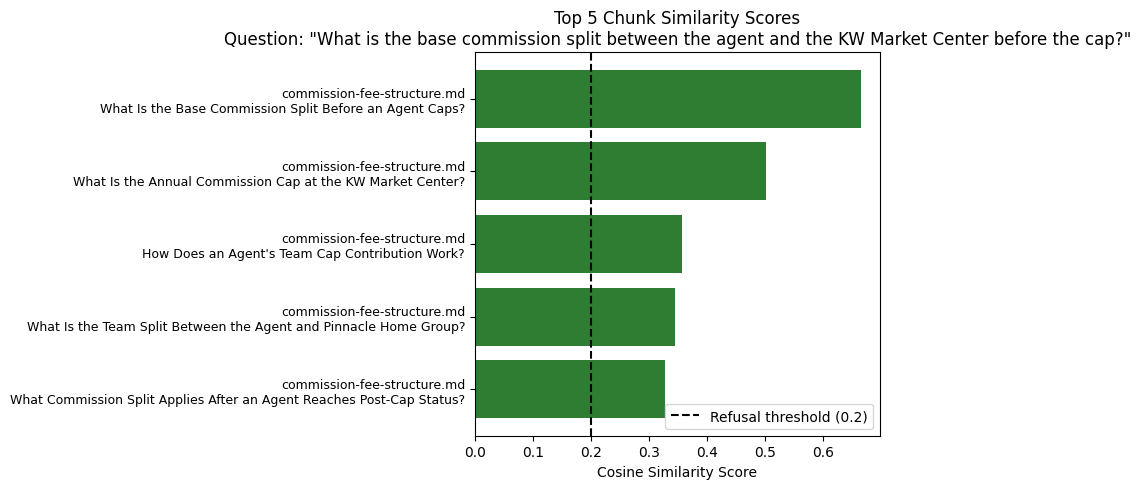

Green bars clear the threshold and would be returned as the answer (the top one is).
Red bars fall below the threshold -- if the TOP bar were red, the chatbot would refuse.


In [10]:
example_question = "What is the base commission split between the agent and the KW Market Center before the cap?"
chosen_threshold = 0.2

cleaned_example = preprocess_text(example_question)
example_vector = vectorizer.transform([cleaned_example])
example_scores = cosine_similarity(example_vector, chunk_vectors)[0]

top5_indices = np.argsort(example_scores)[::-1][:5]
top5_scores = [example_scores[i] for i in top5_indices]
top5_labels = [f"{all_chunks[i]['source']}\n{all_chunks[i]['heading']}" for i in top5_indices]

plt.figure(figsize=(9, 5))
bar_colors = ["#2e7d32" if s >= chosen_threshold else "#c62828" for s in top5_scores]
plt.barh(range(5), top5_scores, color=bar_colors)
plt.yticks(range(5), top5_labels, fontsize=9)
plt.gca().invert_yaxis()
plt.axvline(x=chosen_threshold, color="black", linestyle="--", linewidth=1.5,
            label=f"Refusal threshold ({chosen_threshold})")
plt.xlabel("Cosine Similarity Score")
plt.title(f"Top 5 Chunk Similarity Scores\nQuestion: \"{example_question}\"")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Green bars clear the threshold and would be returned as the answer (the top one is).")
print("Red bars fall below the threshold -- if the TOP bar were red, the chatbot would refuse.")


Interactive Chat

Ask the chatbot questions you believe a new Real Estate Agent may ask their broker during their first few months on the team. You can review the docs above in code cell 2, any of the evaluation questions or generate your own.

In [ ]:
while True:
    user_question = input("Ask the Pinnacle Home Group onboarding bot (or type 'quit' to exit): ")
    if user_question.strip().lower() == "quit":
        print("Goodbye!")
        break
    result = answer(user_question)
    if result["refused"]:
        print(f"Bot: {result['answer']}\n")
    else:
        print(f"Bot: {result['answer']}")
        print(f"     [source: {result['source']} | similarity score: {result['score']:.3f}]\n")
